# Solving Linear Equations Using Substitution and Elimination

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement substitution and elimination techniques for solving linear equations
- Solve systems of linear equations using Python/NumPy
- Compare different methods for solving linear systems
- Apply these techniques to ML-related problems

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — it printed a "closed-form least squares" answer beside the iterative one; obtaining that closed form means solving a linear system.

**Used later in:** Course 04 (AIAT 114) — Unit 1, lesson 04 "Linear Regression" — `LinearRegression` solves this system for you.

---

This notebook covers practical activities from **Course 03, Unit 1**:
- Implementing substitution/elimination techniques for solving linear equations

---

## Introduction

**Substitution and elimination** are fundamental techniques for solving systems of linear equations. In machine learning, these methods are used in solving optimization problems and understanding model parameters.


---

## 📌 Real case: finding a lost planet with a linear system

On 1 January 1801 Giuseppe Piazzi spotted a moving point of light from Palermo. He tracked it 24 times
until illness stopped him on 11 February — about six weeks, covering only a few degrees of sky — and then
the object was swallowed by the Sun's glare and lost. Astronomers across Europe could not find it again.
Carl Friedrich Gauss, then 24, took Piazzi's handful of observations, wrote the orbit as a system of
equations in the unknown orbital elements, and solved it by the method he was inventing as he went:
**least squares**. Franz Xaver von Zach found the object on 31 December 1801, near where Gauss said it
would be. We call it Ceres.

The mechanics are exactly this notebook's. Least squares turns "more observations than unknowns" into a
square system — the **normal equations** (XᵀX)w = Xᵀy — and then you solve it by elimination. Part 4
below does that with five data points and a straight line. Gauss did it with 24 observations and a
heliocentric orbit, by hand.

**What goes wrong without this.** With more measurements than unknowns there is *no* set of orbital
elements that fits every observation exactly, because every observation carries error. Insist on an exact
answer and you have no answer at all. The normal equations replace "make it exact" with "make the total
squared miss as small as possible", and that substitution is what makes a solvable linear system out of
an unsolvable one. Every `LinearRegression().fit()` you will ever call is this move.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: import NumPy (matrix math), Matplotlib (plots), and SciPy's linalg module,
# which provides the industrial-strength linear-system solvers this lesson compares.

import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nSolving Linear Equations Using Substitution and Elimination")
print("=" * 60)


✅ Libraries imported!

Solving Linear Equations Using Substitution and Elimination


## Part 1: Substitution Method


In [2]:
# Worked example: solve a 2-equation system by SUBSTITUTION, the method you'd use by hand.
# Seeing the manual steps first makes the matrix methods later feel like automation, not magic.

print("=" * 60)
print("Part 1: Substitution Method")
print("=" * 60)

# System of equations:
#   (1)  2x + y = 5
#   (2)   x - y = 1
print("\nSystem of equations:")
print("  (1)  2x + y = 5")
print("  (2)   x - y = 1")

# Step 1: Solve equation (2) for x
print("\nStep 1: Solve (2) for x:            x = 1 + y")

# Step 2: Substitute into equation (1)
print("Step 2: Substitute into (1):        2(1 + y) + y = 5  →  2 + 3y = 5")

# Step 3: Solve for y
y = (5 - 2) / 3
print(f"Step 3: Solve for y:                y = (5 - 2) / 3 = {y:.0f}")

# Step 4: Back-substitute to get x
x = 1 + y
print(f"Step 4: Back-substitute:            x = 1 + y = {x:.0f}")

# Verify both equations
print("\nVerification:")
print(f"  (1)  2·{x:.0f} + {y:.0f} = {2 * x + y:.0f}  (expected 5)")
print(f"  (2)   {x:.0f} - {y:.0f} = {x - y:.0f}  (expected 1)")
assert np.isclose(2 * x + y, 5) and np.isclose(x - y, 1)
print("\n✅ Substitution: solve one equation for a variable, substitute into the other!")


Part 1: Substitution Method

System of equations:
  (1)  2x + y = 5
  (2)   x - y = 1

Step 1: Solve (2) for x:            x = 1 + y
Step 2: Substitute into (1):        2(1 + y) + y = 5  →  2 + 3y = 5
Step 3: Solve for y:                y = (5 - 2) / 3 = 1
Step 4: Back-substitute:            x = 1 + y = 2

Verification:
  (1)  2·2 + 1 = 5  (expected 5)
  (2)   2 - 1 = 1  (expected 1)

✅ Substitution: solve one equation for a variable, substitute into the other!


## Part 2: Elimination Method (Gaussian Elimination)


In [3]:
# Implement Gaussian elimination from scratch so the 'solve' button stops being a black box.
# The same forward-eliminate / back-substitute pattern runs inside every linear-algebra library.

print("\n" + "=" * 60)
print("Part 2: Elimination Method (Gaussian Elimination)")
print("=" * 60)

def gaussian_elimination(A, b):
    """Solve Ax = b: forward elimination to row echelon form, then back substitution."""
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)
    # Forward elimination → row echelon form
    for col in range(n - 1):
        # Partial pivoting: bring the row with the largest pivot up (numerical stability)
        pivot_row = np.argmax(np.abs(A[col:, col])) + col
        if pivot_row != col:
            A[[col, pivot_row]] = A[[pivot_row, col]]
            b[[col, pivot_row]] = b[[pivot_row, col]]
        for row in range(col + 1, n):
            factor = A[row, col] / A[col, col]
            A[row, col:] -= factor * A[col, col:]
            b[row] -= factor * b[col]
    # Back substitution
    x = np.zeros(n)
    for row in range(n - 1, -1, -1):
        x[row] = (b[row] - A[row, row + 1:] @ x[row + 1:]) / A[row, row]
    return A, b, x

# Same 2x2 system as Part 1
A2 = np.array([[2, 1], [1, -1]])
b2 = np.array([5, 1])
echelon2, rhs2, sol2 = gaussian_elimination(A2, b2)
print("\n2x2 system:  2x + y = 5,  x - y = 1")
print(f"Row echelon form:\n{echelon2}")
print(f"Transformed right-hand side: {rhs2}")
print(f"Solution by back substitution: x = {sol2[0]:.2f}, y = {sol2[1]:.2f}")

# A 3x3 system (Part 3 solves the same one with NumPy)
A3 = np.array([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]])
b3 = np.array([8, -11, -3])
echelon3, rhs3, sol3 = gaussian_elimination(A3, b3)
print("\n3x3 system:  2x + y - z = 8,  -3x - y + 2z = -11,  -2x + y + 2z = -3")
print(f"Row echelon form:\n{np.round(echelon3, 4)}")
print(f"Solution: x = {sol3[0]:.2f}, y = {sol3[1]:.2f}, z = {sol3[2]:.2f}")

# Cross-check against NumPy
assert np.allclose(sol3, np.linalg.solve(A3, b3))
print("\n✅ Elimination: reduce to row echelon form, back-substitute — matches np.linalg.solve!")



Part 2: Elimination Method (Gaussian Elimination)

2x2 system:  2x + y = 5,  x - y = 1
Row echelon form:
[[ 2.   1. ]
 [ 0.  -1.5]]
Transformed right-hand side: [ 5.  -1.5]
Solution by back substitution: x = 2.00, y = 1.00

3x3 system:  2x + y - z = 8,  -3x - y + 2z = -11,  -2x + y + 2z = -3
Row echelon form:
[[-3.     -1.      2.    ]
 [ 0.      1.6667  0.6667]
 [ 0.      0.      0.2   ]]
Solution: x = 2.00, y = 3.00, z = -1.00

✅ Elimination: reduce to row echelon form, back-substitute — matches np.linalg.solve!


## Part 3: Using NumPy for Linear Systems


In [4]:
# Compare three library routes to the same solution: np.linalg.solve, the explicit inverse, and SciPy.
# Lesson: prefer solve() — inverting a matrix is slower and numerically riskier.

print("\n" + "=" * 60)
print("Part 3: Using NumPy for Linear Systems")
print("=" * 60)

# NumPy provides efficient methods for solving linear systems
A = np.array([[2, 1],
              [1, -1]])
b = np.array([5, 1])

# Method 1: Using np.linalg.solve (recommended)
x_solve = np.linalg.solve(A, b)
print(f"\nUsing np.linalg.solve:")
print(f"Solution: x = {x_solve[0]:.2f}, y = {x_solve[1]:.2f}")

# Method 2: Using inverse matrix (less efficient)
A_inv = np.linalg.inv(A)
x_inv = A_inv @ b
print(f"\nUsing inverse matrix:")
print(f"Solution: x = {x_inv[0]:.2f}, y = {x_inv[1]:.2f}")

# Method 3: Using scipy.linalg.solve
x_scipy = linalg.solve(A, b)
print(f"\nUsing scipy.linalg.solve:")
print(f"Solution: x = {x_scipy[0]:.2f}, y = {x_scipy[1]:.2f}")

print(f"\n✅ All methods give the same result!")

# Example: 3x3 system
print("\n" + "-" * 60)
print("Example: 3x3 System")
print("-" * 60)
A3 = np.array([[2, 1, -1],
               [-3, -1, 2],
               [-2, 1, 2]])
b3 = np.array([8, -11, -3])

x3 = np.linalg.solve(A3, b3)
print(f"\nSystem:")
print("  2x + y - z = 8")
print("  -3x - y + 2z = -11")
print("  -2x + y + 2z = -3")
print(f"\nSolution: x = {x3[0]:.2f}, y = {x3[1]:.2f}, z = {x3[2]:.2f}")
print(f"Verification: A @ x = {A3 @ x3} (expected {b3})")



Part 3: Using NumPy for Linear Systems

Using np.linalg.solve:
Solution: x = 2.00, y = 1.00

Using inverse matrix:
Solution: x = 2.00, y = 1.00

Using scipy.linalg.solve:
Solution: x = 2.00, y = 1.00

✅ All methods give the same result!

------------------------------------------------------------
Example: 3x3 System
------------------------------------------------------------

System:
  2x + y - z = 8
  -3x - y + 2z = -11
  -2x + y + 2z = -3

Solution: x = 2.00, y = 3.00, z = -1.00
Verification: A @ x = [  8. -11.  -3.] (expected [  8 -11  -3])


## Part 4: Application to ML Problems



Part 4: Application to ML Problems

Linear Regression Normal Equations:
------------------------------------------------------------
Design matrix X:
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

X^T * X:
[[ 5. 15.]
 [15. 55.]]
X^T * y:
[20. 66.]

Solution: w0 (bias) = 2.20, w1 (slope) = 0.60
Model: y = 2.20 + 0.60*x


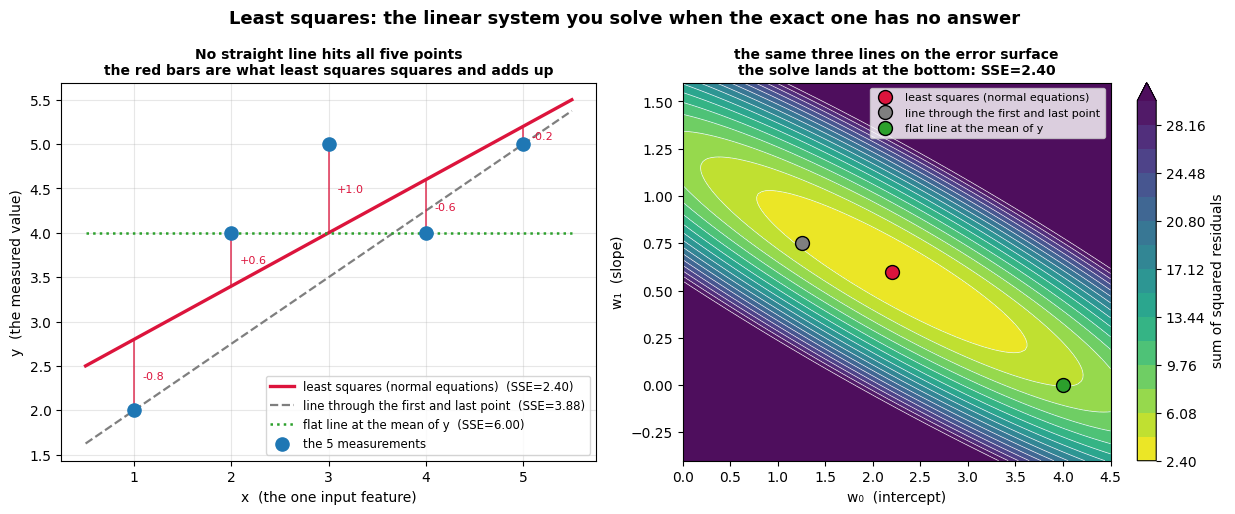


Reading the figure:
------------------------------------------------------------
   least squares (normal equations)       SSE = 2.40
   line through the first and last point  SSE = 3.88
   flat line at the mean of y             SSE = 6.00
   Residuals left by the solved line: [-0.8  0.6  1.  -0.6 -0.2]
   Their squares add to 2.40 - and no other pair (w0, w1) can do better.
   That is the whole claim of the normal equations, and the right panel is the proof:
   the red dot sits in the innermost ring of the bowl.

✅ Linear regression solved using linear equation solving!


In [5]:
# ML payoff: linear regression IS a linear system — the normal equations (X^T X) w = X^T y.
# Solving them with the tools above fits a line to data with no iterative training at all.

print("\n" + "=" * 60)
print("Part 4: Application to ML Problems")
print("=" * 60)

# Example: Linear regression normal equations
# For y = w0 + w1*x, we solve (X^T * X) * w = X^T * y
print("\nLinear Regression Normal Equations:")
print("-" * 60)

# Sample data
X_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([2, 4, 5, 4, 5])

# Create design matrix with bias term
X = np.vstack([np.ones(len(X_data)), X_data]).T

# Normal equations: (X^T * X) * w = X^T * y
A_norm = X.T @ X
b_norm = X.T @ y_data

print(f"Design matrix X:\n{X}")
print(f"\nX^T * X:\n{A_norm}")
print(f"X^T * y:\n{b_norm}")

# Solve for weights
w = np.linalg.solve(A_norm, b_norm)
print(f"\nSolution: w0 (bias) = {w[0]:.2f}, w1 (slope) = {w[1]:.2f}")
print(f"Model: y = {w[0]:.2f} + {w[1]:.2f}*x")

# VISUAL: why this system had to be turned into a least-squares problem at all.
# WHY: five equations, two unknowns - the Ceres situation. No straight line passes through all five
#      points, so the exact system has NO solution. Least squares replaces "be exact" with "make the
#      total squared miss as small as possible", and THAT is the system we just solved.
# HOW: left panel draws the misses (residuals) the solution leaves behind, against two competing lines.
#      Right panel draws the quantity being minimised over every possible (w0, w1), so you can see the
#      solved answer sitting at the bottom of the bowl.


def sum_squared_error(weights):
    """Total squared vertical miss of the line y = w0 + w1*x on these five points."""
    return float(((y_data - (X @ weights)) ** 2).sum())


candidates = {
    "least squares (normal equations)": w,
    "line through the first and last point": np.array([1.25, 0.75]),
    "flat line at the mean of y": np.array([y_data.mean(), 0.0]),
}
styles = {
    "least squares (normal equations)": ("crimson", "-", 2.4),
    "line through the first and last point": ("tab:grey", "--", 1.6),
    "flat line at the mean of y": ("tab:green", ":", 1.8),
}

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.2))

# Left: the data, the three candidate lines, and the residuals the winner leaves.
ax = axes[0]
xs = np.linspace(0.5, 5.5, 50)
for name, weights in candidates.items():
    colour, ls, lw = styles[name]
    ax.plot(xs, weights[0] + weights[1] * xs, color=colour, ls=ls, lw=lw,
            label=f"{name}  (SSE={sum_squared_error(weights):.2f})")
predicted = X @ w
for xi, yi, pi in zip(X_data, y_data, predicted):
    ax.plot([xi, xi], [yi, pi], color="crimson", lw=1.2, alpha=0.8)   # the miss at this point
    ax.annotate(f"{yi - pi:+.1f}", (xi, (yi + pi) / 2), textcoords="offset points",
                xytext=(6, -3), fontsize=8, color="crimson")
ax.scatter(X_data, y_data, s=90, zorder=5, color="tab:blue", label="the 5 measurements")
ax.set_xlabel("x  (the one input feature)")
ax.set_ylabel("y  (the measured value)")
ax.legend(fontsize=8.5, loc="lower right"); ax.grid(alpha=0.3)
ax.set_title("No straight line hits all five points\nthe red bars are what least squares squares and adds up",
             fontsize=10, fontweight="bold")

# Right: the error surface itself. Every point of this plane is a different line.
ax = axes[1]
w0_grid = np.linspace(0.0, 4.5, 120)
w1_grid = np.linspace(-0.4, 1.6, 120)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
S = np.zeros_like(W0)
for i in range(len(X_data)):                       # accumulate the squared miss at each data point
    S += (y_data[i] - (W0 + W1 * X_data[i])) ** 2
levels = np.linspace(S.min(), 30, 16)
cs = ax.contourf(W0, W1, S, levels=levels, cmap="viridis_r", alpha=0.95, extend="max")
ax.contour(W0, W1, S, levels=levels, colors="white", linewidths=0.5)
plt.colorbar(cs, ax=ax, label="sum of squared residuals")
for name, weights in candidates.items():
    colour, _, _ = styles[name]
    ax.plot(weights[0], weights[1], "o", color=colour, ms=10, markeredgecolor="black", label=name)
ax.set_xlabel("w\u2080  (intercept)")
ax.set_ylabel("w\u2081  (slope)")
ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"the same three lines on the error surface\nthe solve lands at the bottom: SSE={sum_squared_error(w):.2f}",
             fontsize=10, fontweight="bold")

fig.suptitle("Least squares: the linear system you solve when the exact one has no answer",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nReading the figure:")
print("-" * 60)
for name, weights in candidates.items():
    print(f"   {name:38s} SSE = {sum_squared_error(weights):.2f}")
print(f"   Residuals left by the solved line: {np.round(y_data - predicted, 2)}")
print(f"   Their squares add to {sum_squared_error(w):.2f} - and no other pair (w0, w1) can do better.")
print("   That is the whole claim of the normal equations, and the right panel is the proof:")
print("   the red dot sits in the innermost ring of the bowl.")

print("\n✅ Linear regression solved using linear equation solving!")


**What to look for in the figure above.** The left panel is the Ceres problem in miniature: five
measurements, two unknowns, and **no** straight line that passes through all five points. The exact
system has no solution at all. The red line is the one the normal equations returned, and the thin red
bars are the misses it leaves — +0.6 at x = 2, +1.0 at x = 3, −0.6 at x = 4, and so on. Least squares
squares those five numbers and adds them: 2.40. The grey line, which passes exactly through the first
and last measurement, leaves 3.88. The green line, which ignores x entirely and predicts the mean of y,
leaves 6.00. Passing through two points exactly is *worse* than missing all five a little.

The right panel is the same three lines seen from above the error surface. Every point of that plane is
a different line: its intercept read off the horizontal axis, its slope off the vertical one, coloured by
the total squared miss it would leave. The surface is a bowl. The red dot sits at the very bottom of it,
alone inside the innermost white ring; the grey dot lies outside that ring, and the green dot sits out
on the next one — the picture-version of 2.40 < 3.88 < 6.00. Solving `(XᵀX)w = Xᵀy` by elimination —
which is all Part 4 did — is how you land on that dot without searching for it.

Notice also that the bowl is a long diagonal valley rather than a round basin. That elongation is the
same ill-conditioning notebook 05 measures: intercept and slope trade off against each other, so many
quite different lines are nearly as good as the winner.

---

## ⚠️ Where this breaks

- **A unique solution is a privilege, not a right.** Every system here had exactly one answer because its
  matrix was square and non-singular. Real ML systems usually are not. With more equations than unknowns
  there is generally *no* exact solution — which is why regression *minimises* a residual instead of
  solving. With more unknowns than equations there are infinitely many, and you must choose one; that
  choice is what regularization does (Unit 3, notebook 04).
- **Gaussian elimination costs about n³ operations.** The 2×2 and 3×3 systems here are free. The normal
  equations for a model with 10,000 features mean a 10,000×10,000 system: roughly 10¹² operations and
  800 MB just to hold the matrix in float64. Past a few thousand parameters the exact solve is the wrong
  tool, and the iterative methods of Unit 2 take over. No neural network is ever trained by solving a
  linear system.
- **Never invert in order to solve.** Part 3 prints `np.linalg.solve`, the explicit inverse, and SciPy all
  agreeing to two decimals. That agreement is a property of *this* well-behaved system, not a property of
  the three methods. `solve` factorises once; `inv` builds an extra object and then multiplies by it,
  accumulating rounding error along the way. Notebook 05 shows a matrix where the gap becomes visible.


---

## 💬 Discuss

1. Gauss had 24 observations and six unknowns and produced a usable orbit. Modern ML routinely has *fewer*
   observations than unknowns. What can "solving" honestly mean in that situation, and who decides which of
   the infinitely many answers you report?
2. Part 3 prints identical answers from three methods and concludes "all methods give the same result."
   Write the sentence you would actually put in an engineering report. What does that agreement license
   you to claim — and what does it not?
3. Linear regression can be solved exactly by elimination, yet every framework you will use trains it
   iteratively instead. Argue both sides: when is the exact solution the right engineering choice, and
   when is it the wrong one?


## Summary

### Key Concepts:
1. **Substitution Method**: Solve one equation for a variable, substitute into other equation
2. **Elimination Method (Gaussian Elimination)**: Transform system to row echelon form, then back substitute
3. **NumPy Methods**: Use `np.linalg.solve()` for efficient solving of linear systems
4. **ML Applications**: Linear regression normal equations, parameter solving

### Best Practices:
- Use NumPy's `linalg.solve()` for numerical stability
- Avoid computing inverse explicitly (use solve instead)
- Check for singular matrices (determinant near zero)
- Verify solutions by checking Ax = b

### Applications:
- Linear regression (normal equations)
- Optimization problems
- Parameter estimation
- Neural network weight solving

**Reference:** Course 03, Unit 1: "Linear Algebra for Machine Learning" - Solving linear equations practical content


## 📚 References

1. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 2: Linear Algebra. Cambridge University Press. <https://mml-book.github.io/>
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 2: Linear Algebra. MIT Press. <https://www.deeplearningbook.org/>
3. Dereziński, M., & Mahoney, M. W. (2024). *Recent and Upcoming Developments in Randomized Numerical Linear Algebra for Machine Learning*. arXiv. <https://arxiv.org/abs/2406.11151> — what replaces exact elimination for least-squares and linear systems at machine-learning scale.
